In [1]:
### load rsi data from the same region in different epochs
### look at how it changes
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from iblatlas.atlas import BrainRegions
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from brainbox.task.trials import get_event_aligned_raster, get_psth
from iblatlas.atlas import AllenAtlas
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from brainbox.population.decode import get_spike_counts_in_bins
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox import singlecell
from tqdm.notebook import tqdm
import seaborn as sns

from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox.singlecell import bin_spikes2D
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path
import warnings
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from ibl_info.utils import generate_source_ids
from glob import glob
from scipy.stats import wilcoxon

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from ibl_info.rsi_collating import (
    collate_pairwise_comparisons,
    convert_pairs_into_arrays,
    collate_pairwise_comparisons_choice,
)

In [4]:
# now for comparison
choice_3bins = np.sort(glob("../data/generated/choice/pseudo/alternate/*.pkl"))
stim_3bins = np.sort(glob("../data/generated/mifiltered/3bins/*.pkl"))

# choice_equi = np.sort(glob("../data/generated/choice/equi/3bins/*.pkl"))
# stim_equi = np.sort(glob("../data/generated/mifiltered/equi/*.pkl"))

In [5]:
pairwise_comparisons_choice_3 = collate_pairwise_comparisons_choice(files=choice_3bins)
final_dict_choice_3 = convert_pairs_into_arrays(pairwise_comparisons_choice_3)


# pairwise_comparisons_choice_equi = collate_pairwise_comparisons_choice(files=choice_equi)
# final_dict_choice_equi = convert_pairs_into_arrays(pairwise_comparisons_choice_equi)

In [6]:
pairwise_comparisons_stim_3 = collate_pairwise_comparisons(files=stim_3bins)
final_dict_stim_3 = convert_pairs_into_arrays(pairwise_comparisons_stim_3)


# pairwise_comparisons_stim_equi = collate_pairwise_comparisons(files=stim_equi)
# final_dict_stim_equi = convert_pairs_into_arrays(pairwise_comparisons_stim_equi)

In [7]:
## what to do?
## match regions and remove the regions that have like 1 pair

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D


def plot_epoch_change_by_case(
    incongruent_stimulus,
    incongruent_choice,
    congruent_stimulus,
    congruent_choice,
    brain_regions,
    save_path="epoch_change_dumbbell_plot.png",
):
    """
    Generates a dumbbell plot showing the change from Stimulus to Choice,
    grouped by Case for each brain region.

    Args:
        incongruent_stimulus (list or np.array): RSI values for Incongruent, Stimulus (1xN regions)
        incongruent_choice (list or np.array): RSI values for Incongruent, Choice (1xN regions)
        congruent_stimulus (list or np.array): RSI values for Congruent, Stimulus (1xN regions)
        congruent_choice (list or np.array): RSI values for Congruent, Choice (1xN regions)
        brain_regions (list): A list of brain region names (length N).
        save_path (str, optional): The file path to save the plot.
    """

    # --- 1. Assemble Data into a DataFrame ---
    # This is the easiest way to manage the data for plotting
    data_list = []
    num_regions = len(brain_regions)

    for i in range(num_regions):
        # Data for Incongruent
        data_list.append(
            {
                "Brain Region": brain_regions[i],
                "Case": "Incongruent",
                "Epoch": "Stimulus",
                "RSI": incongruent_stimulus[i],
            }
        )
        data_list.append(
            {
                "Brain Region": brain_regions[i],
                "Case": "Incongruent",
                "Epoch": "Choice",
                "RSI": incongruent_choice[i],
            }
        )
        # Data for Congruent
        data_list.append(
            {
                "Brain Region": brain_regions[i],
                "Case": "Congruent",
                "Epoch": "Stimulus",
                "RSI": congruent_stimulus[i],
            }
        )
        data_list.append(
            {
                "Brain Region": brain_regions[i],
                "Case": "Congruent",
                "Epoch": "Choice",
                "RSI": congruent_choice[i],
            }
        )

    df = pd.DataFrame(data_list)

    # --- 2. Pivot the Data ---
    # We want 'Stimulus' and 'Choice' as columns to draw the dumbbell
    df_pivot = df.pivot_table(
        index=["Brain Region", "Case"], columns="Epoch", values="RSI"
    ).reset_index()

    # Sort by brain region to ensure a clean y-axis
    df_pivot = df_pivot.sort_values(by="Brain Region")

    # --- 3. Plot the Data ---
    # Get a list of unique brain regions for the y-axis
    regions = df_pivot["Brain Region"].unique()
    y_pos = np.arange(len(regions))

    # Create the figure and axes
    plt.figure(figsize=(12, 8))
    ax = plt.gca()

    # Define colors and offset for the grouped dumbbells
    colors = {"Incongruent": "#1f77b4", "Congruent": "#ff7f0e"}  # Blue, Orange
    y_offset = 0.15  # How far apart to space the two case dumbbells

    # Loop through each case to plot its dumbbell
    for case, color in colors.items():
        # Filter data for the current case
        df_case = df_pivot[df_pivot["Case"] == case]

        # Calculate the vertical position for this case's dumbbell
        # This places 'Incongruent' slightly above the centerline and 'Congruent' slightly below
        current_y_pos = y_pos + (y_offset if case == "Congruent" else -y_offset)

        # Plot the 'bars' (horizontal lines) from Stimulus to Choice
        ax.hlines(
            y=current_y_pos,
            xmin=df_case["Stimulus"],
            xmax=df_case["Choice"],
            color=color,
            alpha=0.7,
            linewidth=2,
            label=f"{case} Change",
        )

        # Plot the 'dots' (scatter points)
        # We use a circle for Stimulus and a square for Choice
        ax.scatter(
            df_case["Stimulus"], current_y_pos, color=color, s=100, zorder=3, alpha=0.9, marker="o"
        )
        ax.scatter(
            df_case["Choice"], current_y_pos, color=color, s=100, zorder=3, alpha=0.9, marker="s"
        )

    # --- 4. Customize and Save ---
    ax.set_yticks(y_pos)
    ax.set_yticklabels(regions, fontsize=12)
    ax.invert_yaxis()  # Puts the first region at the top
    ax.set_xlabel("RSI Value", fontsize=14)
    ax.set_ylabel("Brain Region", fontsize=14)
    ax.set_title("RSI Change from Stimulus to Choice, by Case", fontsize=16, pad=20)

    # Add a custom legend
    legend_elements = [
        Line2D([0], [0], color=colors["Incongruent"], lw=2, label="Incongruent"),
        Line2D([0], [0], color=colors["Congruent"], lw=2, label="Congruent"),
        Line2D(
            [0],
            [0],
            marker="o",
            color="gray",
            label="Stimulus",
            markerfacecolor="gray",
            markersize=10,
            ls="",
        ),
        Line2D(
            [0],
            [0],
            marker="s",
            color="gray",
            label="Choice",
            markerfacecolor="gray",
            markersize=10,
            ls="",
        ),
    ]
    ax.legend(
        handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=4, fontsize=12
    )

    plt.grid(axis="x", linestyle="--", alpha=0.6)
    plt.tight_layout()

In [9]:
# IC, C, A
def arrange_dumbell_data(choice, stimulus):

    congruent_choice = []
    congruent_stimulus = []
    incongruent_choice = []
    incongruent_stimulus = []
    plot_rnames = []
    region_names = choice["region_names"]

    for idx, r in enumerate(region_names):

        if r == "MG" or r == "SNr":
            print(f"we skip {r}")
            continue
        incongruent_choice.append(choice["region_means_rsi"][idx, 0])
        incongruent_stimulus.append(stimulus["region_means_rsi"][idx, 0])

        congruent_choice.append(choice["region_means_rsi"][idx, 1])
        congruent_stimulus.append(stimulus["region_means_rsi"][idx, 1])

        plot_rnames.append(r)
    return (
        plot_rnames,
        np.asarray(incongruent_choice),
        np.asarray(incongruent_stimulus),
        np.asarray(congruent_choice),
        np.asarray(congruent_stimulus),
    )

In [58]:
regions, inc_choice, inc_stim, con_choice, con_stim = arrange_dumbell_data(
    final_dict_choice_3, final_dict_stim_3
)

we skip MG
we skip SNr


In [60]:
regions_nx = np.concatenate([regions, ["Mean"]])

In [17]:
colors = ["#FDBF6F", "#A6CEE3"]

In [18]:
delta_con = con_choice - con_stim
delta_incon = inc_choice - inc_stim

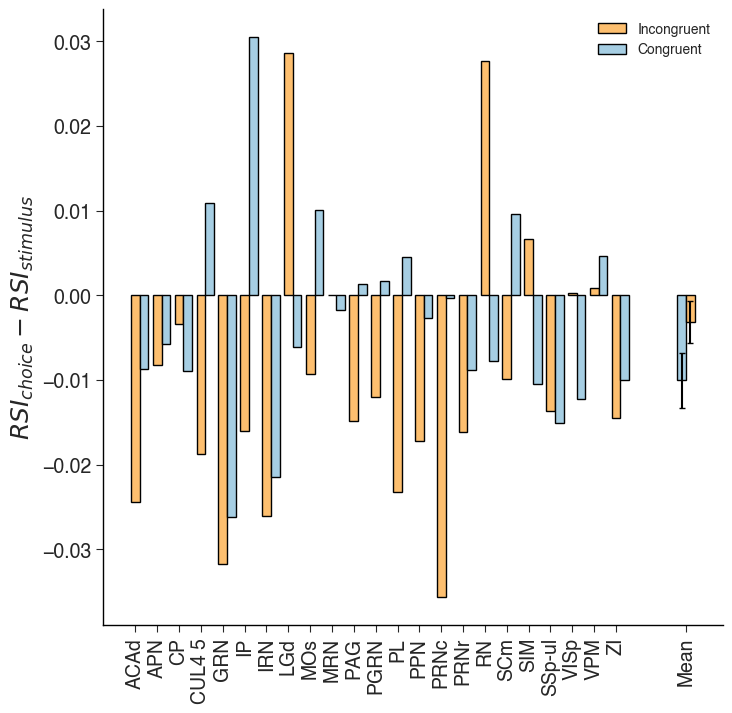

In [137]:
plt.style.use("../figures.style")

fig, ax = plt.subplots(figsize=(8, 8))
sns.despine()
ax.bar(
    np.arange(len(regions)),
    delta_incon,
    color=colors[0],
    edgecolor="k",
    width=0.4,
    label="Incongruent",
)
ax.bar(
    np.arange(len(regions)) + 0.4,
    delta_con,
    color=colors[1],
    edgecolor="k",
    width=0.4,
    label="Congruent",
)
ax.bar(
    np.asarray([0, 0.4]) + len(regions) + 2,
    [np.mean(delta_incon), np.mean(delta_con)],
    yerr=[np.std(delta_incon), np.std(delta_con)] / np.sqrt(len(regions)),
    color=np.asarray(colors)[::-1],
    edgecolor="k",
    width=0.4,
    capsize=2,
)
ax.set_ylabel("$RSI_{choice} - RSI_{stimulus}$")
ax.set_xticks(
    np.concatenate([np.arange(len(regions)), np.asarray([0.2]) + len(regions) + 2]),
    regions_nx,
    rotation=90,
)
ax.legend()

In [69]:
# fig, ax = plt.subplots(figsize=(8, 6))
# sns.despine()
# plt.bar(
#     np.arange(2),
#     [np.mean(delta_incon), np.mean(delta_con)],
#     yerr=[np.std(delta_incon), np.std(delta_con)] / np.sqrt(len(regions)),
#     color=np.asarray(colors)[::-1],
#     edgecolor="k",
# )
# ax.set_ylabel("$RSI_{choice} - RSI_{stimulus}$")
# ax.set_xticks(np.arange(2), ["Incongruent", "Congruent"])
# plt.title("means")

In [70]:
# proper delta
# load animal
# if animal exists in both
# then compute deltas

In [11]:
from ibl_info.rsi_collating import compute_rsivstvmi

In [10]:
def rsi_region_comparator(region_data_stim, region_data_choice):
    rsi_congruent_stim = []
    rsi_incongruent_stim = []

    rsi_congruent_choice = []
    rsi_incongruent_choice = []

    for eid in region_data_stim.keys():
        data_stim = region_data_stim[eid]

        if eid not in region_data_choice.keys():
            continue

        data_choice = region_data_choice[eid]
        try:
            rsi_c_stim, _, _ = compute_rsivstvmi(data_stim["subsampled"])  # type: ignore
            rsi_ic_stim, _, _ = compute_rsivstvmi(data_stim["incongruent"])  # type: ignore

            rsi_c_choice, _, _ = compute_rsivstvmi(data_choice["subsampled"])  # type: ignore
            rsi_ic_choice, _, _ = compute_rsivstvmi(data_choice["incongruent"])  # type: ignore

            rsi_congruent_choice.append(rsi_c_choice)
            rsi_incongruent_choice.append(rsi_ic_choice)

            rsi_congruent_stim.append(rsi_c_stim)
            rsi_incongruent_stim.append(rsi_ic_stim)

        except Exception as e:
            print(e, eid)
    # rsi_incongruent = np.concatenate(rsi_incongruent)
    # rsi_congruent = np.concatenate(rsi_congruent)

    return (
        np.asarray(rsi_incongruent_choice),
        np.asarray(rsi_congruent_choice),
        np.asarray(rsi_incongruent_stim),
        np.asarray(rsi_congruent_stim),
    )

In [12]:
global_deltas = {}
for idx in range(len(choice_3bins)):
    region_name_choice = choice_3bins[idx].rsplit("_choice_filtered_")[0].rsplit("_")[-1]
    region_name_stim = stim_3bins[idx].rsplit("_stim_filtered_")[0].rsplit("_")[-1]
    assert region_name_choice == region_name_stim
    if region_name_choice == "MG" or region_name_choice == "SNr":
        print(f"we skip {region_name_choice}")
        continue
    temp = {}

    with open(choice_3bins[idx], "rb") as f:
        fx_choice = pkl.load(f)
    with open(stim_3bins[idx], "rb") as f:
        fx_stim = pkl.load(f)
    rsi_ic_choice, rsi_c_choice, rsi_ic_stim, rsi_c_stim = rsi_region_comparator(
        fx_stim, fx_choice
    )
    ic_delta = rsi_ic_choice - rsi_ic_stim
    c_delta = rsi_c_choice - rsi_c_stim
    temp["ic_delta"] = ic_delta
    temp["c_delta"] = c_delta
    global_deltas[region_name_choice] = temp

we skip MG
we skip SNr


In [13]:
plot_means = []
plot_stds = []
plot_labels = []
weights = []
for k in global_deltas.keys():
    dx = global_deltas[k]
    if len(dx["ic_delta"]) < 1:
        continue
    plot_labels.append(k)
    ic_delta_mean = np.nanmean(dx["ic_delta"])
    c_delta_mean = np.nanmean(dx["c_delta"])
    weights.append(np.count_nonzero(dx["ic_delta"]))

    ic_delta_sem = np.nanstd(dx["ic_delta"]) / np.sqrt(len(dx["ic_delta"]))
    c_delta_sem = np.nanstd(dx["c_delta"]) / np.sqrt(len(dx["c_delta"]))

    plot_means.append([ic_delta_mean, c_delta_mean])
    plot_stds.append([ic_delta_sem, c_delta_sem])

plot_means = np.asarray(plot_means)
plot_stds = np.asarray(plot_stds)

In [14]:
weighted_mean = np.average(plot_means, weights=weights, axis=0)

In [18]:
colors = ["#FDBF6F", "#A6CEE3"]

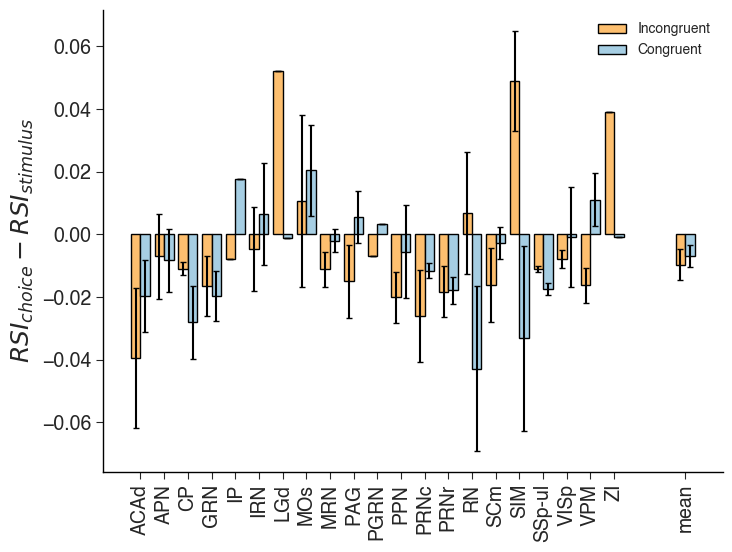

In [22]:
plt.style.use("../figures.style")
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(
    np.arange(len(plot_labels)),
    plot_means[:, 0],
    width=0.4,
    yerr=plot_stds[:, 0],
    color=colors[0],
    edgecolor="k",
    label="Incongruent",
    capsize=2,
)
ax.bar(
    np.arange(len(plot_labels)) + 0.4,
    plot_means[:, 1],
    width=0.4,
    yerr=plot_stds[:, 1],
    color=colors[1],
    edgecolor="k",
    label="Congruent",
    capsize=2,
)


ax.bar(
    np.asarray([0, 0.4]) + len(plot_labels) + 2,
    weighted_mean,
    width=0.4,
    yerr=np.std(plot_means, axis=0) / np.sqrt(len(plot_means)),
    color=colors,
    edgecolor="k",
    capsize=2,
)

new_plt_labels = np.concatenate([plot_labels, ["mean"]])
ax.set_xticks(
    np.concatenate([np.arange(len(plot_labels)) + 0.2, np.asarray([2.2]) + len(plot_labels)]),
    new_plt_labels,
    rotation=90,
)
ax.set_ylabel("$RSI_{choice} - RSI_{stimulus}$")
ax.legend()
plt.savefig("../reports/figures/changeinrsi.png", facecolor="white", bbox_inches="tight", dpi=300)

In [30]:
plot_labels

['ACAd',
 'APN',
 'CP',
 'GRN',
 'IP',
 'IRN',
 'LGd',
 'MOs',
 'MRN',
 'PAG',
 'PGRN',
 'PPN',
 'PRNc',
 'PRNr',
 'RN',
 'SCm',
 'SIM',
 'SSp-ul',
 'VISp',
 'VPM',
 'ZI']

In [31]:
# load cortical hieararchy

cortical_h = pd.read_excel("../../MouseBrainHierarchy/Output/TCCT_CCconf_iter.xls")
cortical_h = cortical_h.sort_values(by=20)
subset_cortical_h = cortical_h[cortical_h["areas"].isin(plot_labels)].copy()
subset_cortical_h["index"] = np.arange(len(subset_cortical_h))

# now we look

hierarchy_values = subset_cortical_h["index"].values

In [33]:
subset_cortical_h

,Unnamed: 0,areas,CortexThalamus,0,20,index
60,60,VPM,T,-0.941176,-1.023648,0
17,17,LGd,T,-0.625000,-0.632912,1
53,53,VISp,C,-0.334568,-0.420983,2
44,44,SSp-ul,C,-0.163636,-0.187118,3
22,22,MOs,C,0.179946,0.315826,4
0,0,ACAd,C,0.236876,0.358589,5


In [35]:
files_choice = np.sort(glob("../data/generated/choice/pseudo/alternate/*.pkl"))
pairwise_choice = collate_pairwise_comparisons_choice(files_choice)
# del pairwise_choice["MG"]
final_dict_choice = convert_pairs_into_arrays(pairwise_choice)


files_stim = np.sort(glob("../data/generated/mifiltered/3bins/*.pkl"))
pairwise_stim = collate_pairwise_comparisons(files_stim)
# del pairwise_stim["MG"]
final_dict_stim = convert_pairs_into_arrays(pairwise_stim)

In [41]:
areas_needed = subset_cortical_h.areas.values

In [56]:
reqd_indices_stim = np.where(np.isin(final_dict_stim["region_names"], areas_needed))[0]

reqd_indices_choice = np.where(np.isin(final_dict_choice["region_names"], areas_needed))[0]

In [58]:
reqd_stim_rsi = final_dict_stim["region_means_rsi"][reqd_indices_stim, :]
reqd_choice_rsi = final_dict_choice["region_means_rsi"][reqd_indices_choice, :]

reqd_stim_tvmi = final_dict_stim["region_means_tvmi"][reqd_indices_stim, :]
reqd_choice_tvmi = final_dict_choice["region_means_tvmi"][reqd_indices_choice, :]

In [66]:
np.asarray(final_dict_choice["region_names"])[reqd_indices_choice]

array(['ACAd', 'LGd', 'MOs', 'SSp-ul', 'VISp', 'VPM'], dtype='<U6')

In [71]:
subset_cortical_h

,Unnamed: 0,areas,CortexThalamus,0,20,index
60,60,VPM,T,-0.941176,-1.023648,0
17,17,LGd,T,-0.625000,-0.632912,1
53,53,VISp,C,-0.334568,-0.420983,2
44,44,SSp-ul,C,-0.163636,-0.187118,3
22,22,MOs,C,0.179946,0.315826,4
0,0,ACAd,C,0.236876,0.358589,5


In [91]:
# load cortical hieararchy
def cortical_H_plots(final_dict):
    cortical_h = pd.read_excel("../../MouseBrainHierarchy/Output/TCCT_CCconf_iter.xls")
    # cortical_h = pd.read_excel("../../MouseBrainHierarchy/Output/TC_CCconf_iter.xls")
    cortical_h = cortical_h.sort_values(by=20)
    subset_cortical_h = cortical_h[cortical_h["areas"].isin(final_dict["region_names"])].copy()
    subset_cortical_h["index"] = np.arange(len(subset_cortical_h))

    # now we look
    region_names = np.asarray(final_dict["region_names"])
    number_of_regions = final_dict["number_of_regions"]
    region_means_rsi = final_dict["region_means_rsi"]
    region_means_count = final_dict["region_means_count"]
    hieararchy_values = []
    filtered_regions = []
    color = ["#FDBF6F", "#A6CEE3"]
    for idx in range(len(subset_cortical_h)):
        region_idx = np.argwhere(region_names == subset_cortical_h.iloc[idx]["areas"])[0]
        # combine all together, based on number though
        # counts are in IC, C, A
        if region_means_count[region_idx, 3] == 1:
            if region_means_count[region_idx, 0] == 2:
                # print(f"We skip: {region_names[region_idx]}")
                continue
        else:
            # we grok incongruent rsi and congruent rsi
            hieararchy_values.append(
                [
                    region_means_rsi[region_idx, 0],
                    region_means_rsi[region_idx, 1],
                    region_means_rsi[region_idx, 2],
                ]
            )
            filtered_regions.append(region_names[region_idx][0])
    hieararchy_values = np.asarray(hieararchy_values).squeeze()

    fig, ax = plt.subplots(figsize=(12, 4), ncols=2, sharey=True)
    ax[0].bar(
        np.arange(6), hieararchy_values[:, 0], label="Incongruent", color=color[0], edgecolor="k"
    )
    ax[1].bar(
        np.arange(6), hieararchy_values[:, 1], label="Congruent", color=color[1], edgecolor="k"
    )
    ax[0].set_ylabel("RSI")
    ax[0].set_xticks(np.arange(6), filtered_regions)
    ax[1].set_xticks(np.arange(6), filtered_regions)
    ax[0].legend()
    ax[1].legend()

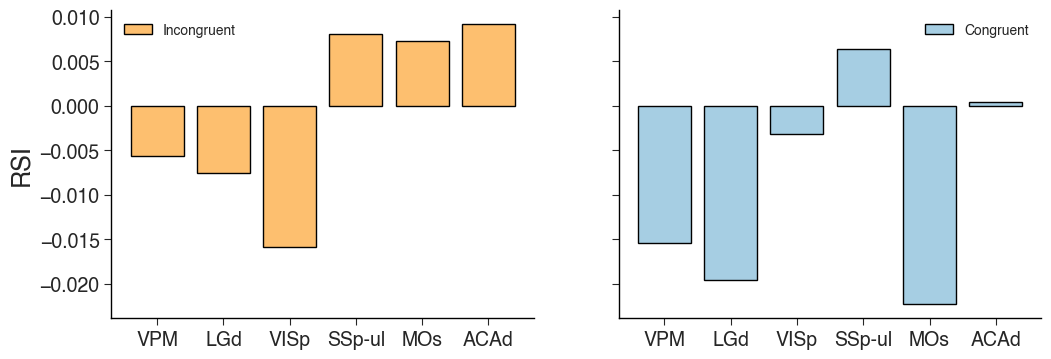

In [92]:
cortical_H_plots(final_dict_stim)

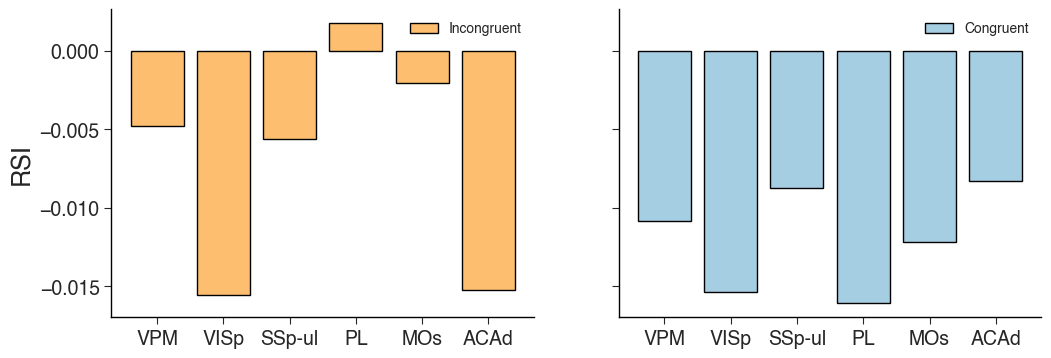

In [93]:
cortical_H_plots(final_dict_choice)

In [94]:
# what about deltas

In [100]:
# plot delta by cortical hierarchy

hiear_plots = []
for idx in range(len(areas_needed)):

    for idy in range(len(plot_labels)):
        if areas_needed[idx] == plot_labels[idy]:
            hiear_plots.append(plot_means[idy, :])

In [101]:
hiear_plots = np.asarray(hiear_plots)

<BarContainer object of 6 artists>

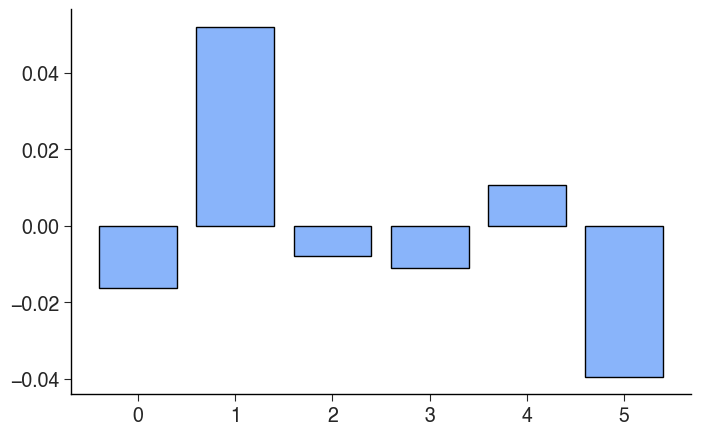

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(np.arange(6), hiear_plots[:, 0], edgecolor="k")


<BarContainer object of 6 artists>

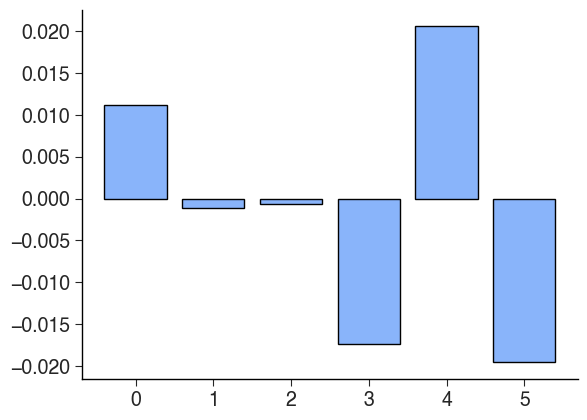

In [107]:
plt.bar(np.arange(6), hiear_plots[:, 1], edgecolor="k")